In [7]:
colab = False
if colab:
    !git clone https://github.com/mdrs-thiago/PUC_Redes_Neurais
    import os
    os.chdir('/content/PUC_Redes_Neurais/pos_grad/lista 1')

# Redes Neurais
## 1ª Lista de Exercícios - Classificação de padrões


Estudante: Carlos Alberto de Souza Moreira Junior Matricula 2612398

Base de dados: bank Market

### Para cada item da lista de exercício, não esqueça de fazer uma análise pertinente dos resultados obtidos.

### Guia prático

A lista de exercícios é dividida em 4 partes. Cada questão possui as seguintes seções:

* **Rascunho**: neste espaço, você pode escrever qualquer código ou teste que queira fazer, mas que *não* produza a resposta desejada.

* **Resposta**: deve conter trechos do código que produzam artefatos importantes para a análise de resultados, além de comentários e discussões sobre o item.

Não é necessário seguir esta ordem, mas é *altamente recomendável*. O intuito da lista de exercícios **não** é medir o nível de conhecimento em programação, então não se preocupe se o código não estiver da forma mais polida possível. O principal ponto a ser avaliado é a capacidade crítica de entender os fenômenos atrelados aos resultados obtidos e a discussão de resultados para um problema específico.   

Outros pontos importantes:

1. Fique atento com os hiperparâmetros iniciais desta lista. Dependendo do problema, os valores podem mudar. Para encontrar um conjunto de parâmetros razoáveis, siga o seguinte roteiro: 

    * Rode os itens 2.1 e 3.1 com os parâmetros iniciais. Se os dois resultados foram igualmente ruins, modifique os parâmetros do item 3.1 até que o resultado seja relativamente melhor que o 2.1.

    * Após obter esses melhores parâmetros iniciais, rode novamente o item 2.1 com os mesmos hiperparâmetros para uma comparação mais justa. 

2. O resultado de um modelo de Redes Neurais geralmente depende da inicialização de seus pesos. Portanto, para cada questão, obtenha um resultado médio de pelo menos 10 rodadas. A recomendação pessoal é de que faça uso do histórico existente da perda (loss) e acurácia para visualização dos resultados, com plot da média e seu intervalo de confiança em função das épocas.

In [8]:
import numpy as np 
import pandas as pd 
import json
import matplotlib.pyplot as plt 
import seaborn as sns 
from time import sleep
import requests

import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader 

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from utils import CustomDataset, transform_data, plot_confusion_matrix

from typing import Tuple, Dict, List
from tqdm import tqdm 

In [9]:
def accuracy(y_pred: torch.Tensor, y_test: torch.Tensor) -> float:
    """
    Computes the accuracy of a PyTorch model given the outputs and labels.

    Parameters:
        outputs (torch.Tensor): The model outputs.
        labels (torch.Tensor): The true labels.

    Returns:
        float: The accuracy of the model.
    """
    
    _, predictions = torch.max(y_pred, dim=1)
    correct = torch.sum(predictions == y_test)
    accuracy = correct.float() / y_test.size(0)
    acc = torch.round(accuracy * 100)
    
    return acc

def binary_acc(y_pred: torch.Tensor, y_test: torch.Tensor) -> float:
    """
    Computes the binary accuracy of a PyTorch model given the outputs and labels.

    Parameters:
        outputs (torch.Tensor): The model outputs.
        labels (torch.Tensor): The true labels.

    Returns:
        float: The accuracy of the model.
    """
    
    predictions = torch.round(torch.sigmoid(y_pred))
    correct = torch.sum(predictions == y_test)
    accuracy = correct.float() / y_test.size(0)
    acc = torch.round(accuracy * 100)
    
    return acc

In [10]:
def evaluate(model: torch.nn.Module, val_set: Tuple[torch.tensor, torch.tensor], 
            criterion: torch.nn.Module, binary:bool =True) -> Tuple[torch.tensor, float, float]:
    """
    Evaluates a Pytorch model on a given dataset.
    Parameters:
    model (torch.nn.Module): The model to be evaluated
    data (tuple): A tuple containing the data and labels
    criterion (torch.nn.Module): The loss function to be used
    binary (bool): Boolean indicating whether the task is binary classification or not. Default: True
    Returns:
    tuple: A tuple containing predicted labels, loss, and accuracy
    """
    
    X = val_set.X_data
    y = val_set.y_data
    
    with torch.no_grad():
        y_pred = model(X)
    loss = criterion(y_pred, y)
    if binary:
        acc = binary_acc(y_pred, y)
    else:
        acc = accuracy(y_pred, y)
    y_pred = torch.argmax(y_pred, dim=1)

    return y_pred, loss.item(), acc.item()


In [11]:
def train(model: torch.nn.Module , train_loader: torch.utils.data.DataLoader, 
         val_set: Tuple[torch.Tensor, torch.Tensor], epochs: int, device: torch.device, 
         lr: float, binary: bool = True, skip: int = 1) -> Tuple[Dict[str, List[float]], torch.Tensor]:
    """
    Trains a Pytorch model on a given training data.

    Parameters:
    model (torch.nn.Module): The model to be trained
    train_loader (DataLoader): The training data in the form of a Pytorch DataLoader
    val_set (tuple): A tuple containing the validation data and labels
    epochs (int): The number of times the training data should be passed through the model
    device (str or torch.device): The device on which to perform the computations (e.g. 'cpu' or 'cuda')
    lr (float): The learning rate for the optimizer
    binary (bool): Boolean indicating whether the task is binary classification or not. Default: True
    skip (int): The number of epochs after which the training and validation results will be printed. Default: 1

    Returns:
    tuple: A tuple containing the training history and the predicted labels after training
    """

    if binary:
        criterion = nn.BCEWithLogitsLoss()
    else:
        criterion = nn.CrossEntropyLoss()


    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    history = {'acc_train' : [], 'loss_train': [], 'acc_val': [], 'loss_val': []}

    for e in tqdm(range(1, epochs+1)):

        y_hat = np.array([])

        train_epoch_loss = 0
        train_epoch_acc = 0
        model.train()
        for X_train_batch, y_train_batch in train_loader:
            X, y = X_train_batch.to(device), y_train_batch.to(device)
            optimizer.zero_grad()
            
            y_pred = model(X)
            
            loss = criterion(y_pred, y)
            if binary:
                acc = binary_acc(y_pred,y)
            else:
                acc = accuracy(y_pred, y)
            
            loss.backward()
            optimizer.step()
            
            train_epoch_loss += loss.item()
            train_epoch_acc += acc.item()
            y_p = torch.argmax(y_pred, dim=1)
            y_hat = np.concatenate((y_hat, y_p))


        model.eval()
        _, val_loss, val_acc = evaluate(model, val_set, criterion, binary=binary)

        history['acc_train'].append(train_epoch_acc/len(train_loader))
        history['loss_train'].append(train_epoch_loss/len(train_loader))
        history['acc_val'].append(val_acc)
        history['loss_val'].append(val_loss)

        if e%skip == 0:
            print(f'Epoch {e+0:03}: | Train Loss: {train_epoch_loss/len(train_loader):.3f} | Val Loss: {val_loss:.4f} | Train Acc: {train_epoch_acc/len(train_loader):.4f}| Val Acc: {val_acc:.4f}')
    return history, y_hat

In [12]:
class NeuralNetwork(torch.nn.Module):
  '''
  Objeto criado para facilitar o desenvolvimento dos scripts das aulas práticas.
  Opção alternativa à criação externa fdo modelo. Basicamente serve como um 
  'agregador'  de trechos comuns para a criação do modelo. Por exemplo, ao invés
  de gastar n+1 linhas para a criação de um modelo com n camadas, podemos criar 
  o mesmo modelo com apenas uma linha.
  
  Parâmetros de entrada: 
  - hidden_neurons: Lista com a quantidade de neurônios na camada escondida. 
  - hidden_activation: Função de ativação para cada camada escondida. Aceita 
  como parâmetro string ou lista. Caso o parâmetro receba string, então a mesma
  função de ativação é utilizada para todas as camadas escondidas. Caso seja uma 
  lista, cada camada terá sua propria função de ativação definida pela lista.
  - output_activation: Função de ativação para a camada de saída.
  - lr: Taxa de aprendizado
  - n_input: Tamanho do vetor de entrada.
  - n_output: Saída do modelo.
  '''
  def __init__(self,hidden_neurons = 4, hidden_activation = 'relu', output_activation='softmax', lr = 0.05, n_input = 1, n_output = 1):
    super(NeuralNetwork, self).__init__()

    self.activations = {'relu': nn.ReLU(), 'sigmoid':nn.Sigmoid(), 'softmax':nn.Softmax()}

    self.fc1 = nn.Linear(n_input, hidden_neurons)
    self.ha = self.activations[hidden_activation]
    self.fc2 = nn.Linear(hidden_neurons, n_output)

  def forward(self,x):
    h = self.fc1(x)
    h1 = self.ha(h) 
    y = self.fc2(h1) 
    return y

  def predict(self, x, binary=True):
    y_hat = self.forward(x)

    if binary:
      y_pred = torch.round(torch.sigmoid(y_hat))
      y_pred = y_pred.detach().numpy()
    else:
      y_pred = torch.argmax(y_hat, dim=1)

    return y_pred

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

/home/carlos/.local/lib/python3.13/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


# Preparação dos dados

Não esqueça de verificar o path para a pasta. Mude também o filename, de acordo com a base de dados. Esta parte é necessária para garantir que as colunas sejam corretamente identificadas de acordo com a natureza dos dados.

In [25]:
dataset_name = 'bank_marketing'
base_raw = 'https://raw.githubusercontent.com/mdrs-thiago/PUC_Redes_Neurais/main/datasets'
dataset_path = f'{base_raw}/c_{dataset_name}.csv'
info_path = f'{base_raw}/data_info/{dataset_name}/data_info.json'
local_dataset_path = f'../../datasets/c_{dataset_name}.csv'

#não consegui acessar direto o  dataset
try:
    dataset = pd.read_csv(dataset_path)
except Exception:
    if dataset_name == 'bank_marketing':
        from io import BytesIO
        from zipfile import ZipFile

        uci_bank_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip'
        zip_bytes = requests.get(uci_bank_url, timeout=30).content
        with ZipFile(BytesIO(zip_bytes)) as zf:
            with zf.open('bank-full.csv') as f:
                dataset = pd.read_csv(f, sep=';')
    else:
        dataset = pd.read_csv(local_dataset_path)

if 'y' in dataset.columns and 'target' not in dataset.columns:
    dataset = dataset.rename(columns={'y': 'target'})

In [26]:
resp = requests.get(info_path)
info = json.loads(resp.text)

In [27]:
for col, k in info.items():
    if k == 'categorical':
        dataset[col] = dataset[col].astype(object)

In [28]:
for i in dataset.dtypes.items():
    print(i)

('age', dtype('int64'))
('job', dtype('O'))
('marital', dtype('O'))
('education', dtype('O'))
('default', dtype('O'))
('balance', dtype('int64'))
('housing', dtype('O'))
('loan', dtype('O'))
('contact', dtype('O'))
('day', dtype('int64'))
('month', dtype('O'))
('duration', dtype('int64'))
('campaign', dtype('int64'))
('pdays', dtype('int64'))
('previous', dtype('int64'))
('poutcome', dtype('O'))
('target', dtype('O'))


In [29]:
# Visao geral do dataset bank_marketing
print(f"Dataset selecionado: {dataset_name}")
print(f"Dimensao: {dataset.shape[0]} linhas x {dataset.shape[1]} colunas")

print("\nPrimeiras 5 linhas:")
display(dataset.head())

print("\nInformacoes das colunas:")
display(dataset.dtypes.to_frame(name='dtype').T)

if 'target' in dataset.columns:
    print("\nDistribuicao da variavel alvo (target):")
    display(dataset['target'].value_counts(dropna=False).to_frame(name='count').T)

Dataset selecionado: bank_marketing
Dimensao: 45211 linhas x 17 colunas

Primeiras 5 linhas:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,target
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no



Informacoes das colunas:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,target
dtype,int64,object,object,object,object,int64,object,object,object,int64,object,int64,int64,int64,int64,object,object



Distribuicao da variavel alvo (target):


target,no,yes
count,39922,5289


## Parte I - Compreensão do problema e análise de variáveis

Total: 0,5 pts.


1)	Neste primeiro momento, iremos verificar a qualidade dos dados. Verifique se os dados estão aptos para o treinamento de Redes Neurais (i.e., verifique a existência de dados nulos, atributos de identificação ou duplicados). Implemente o código que execute as técnicas necessárias e discuta o racional utilizado para o tratamento de dados. 

Rascunho

In [30]:
# PSEUDOCODIGO (Rascunho)
# 1. Inspecionar dimensao da base e tipos das colunas.
# 2. Verificar dados nulos por coluna.
# 3. Verificar duplicatas completas e remover, se houver.
# 4. Procurar colunas candidatas a identificador (nome com "id" ou alta cardinalidade).
# 5. Definir estrategia de tratamento e aplicar no dataset.

Resposta

1) INSPECAO INICIAL DA BASE
- Dimensao inicial: 45211 linhas x 17 colunas
- Tipos das colunas (amostra):
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
dtype: object

2) DADOS NULOS
- Nao foram encontrados valores nulos explicitos.

3) DUPLICATAS
- Duplicatas completas antes: 0
- Duplicatas completas depois: 0
- Acao: nenhuma remocao necessaria.

4) ATRIBUTOS CANDIDATOS A IDENTIFICADOR
- Candidatas encontradas: []
- Colunas efetivamente removidas: []

5) CATEGORIAS UNKNOWN POR COLUNA CATEGORICA
- Tabela geral de unknown por coluna:


,coluna,qtd_unknown,pct_unknown
0,poutcome,36959,81.75
1,contact,13020,28.80
2,education,1857,4.11
3,job,288,0.64


- Mini tabela (colunas foco):


,coluna,qtd_unknown,pct_unknown
0,poutcome,36959,81.75
1,contact,13020,28.80
2,education,1857,4.11
3,job,288,0.64


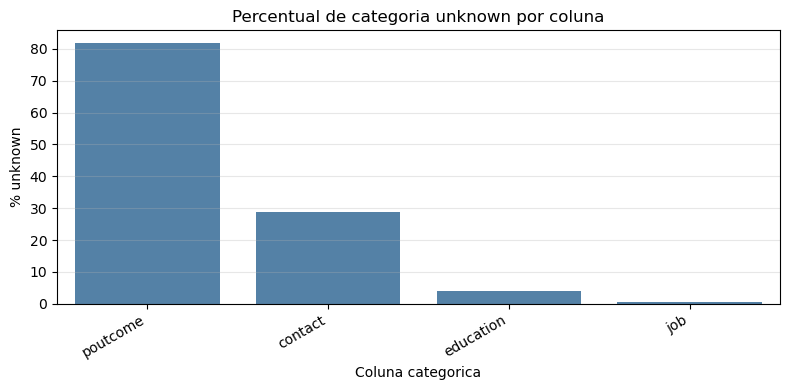


6) DISTRIBUICAO DA VARIAVEL-ALVO
- Contagem por classe:
target
no     39922
yes     5289
Name: count, dtype: int64
- Percentual por classe (%):
target
no     88.3
yes    11.7
Name: count, dtype: float64
- Razao majoritaria/minoritaria: 7.55
- Observacao: ha desbalanceamento relevante; accuracy isolada pode ser enganosa.

7) ESTRATEGIA APLICADA
- Estrategia: remover duplicatas e remover possiveis identificadores (quando encontrados).
- Ressalva: categorias como "unknown" e o possivel desbalanceamento da classe-alvo exigem cuidado na analise.
- Dimensao final apos tratamento: 45211 linhas x 17 colunas

Conclusao da Questao 1: base utilizavel para as proximas etapas, com ressalvas sobre categorias "unknown" e sobre o desbalanceamento da classe-alvo.


In [31]:
# Questao 1 - Implementacao com saidas explicitas por etapa do pseudocodigo

def check_data_quality(df: pd.DataFrame, target_col: str = 'target', id_threshold: float = 0.98) -> dict:
    nulls = df.isna().sum()
    n_duplicates = int(df.duplicated().sum())

    id_candidates = []
    for col in df.columns:
        if col == target_col:
            continue
        unique_ratio = df[col].nunique(dropna=False) / max(len(df), 1)
        if ('id' in col.lower()) or (unique_ratio >= id_threshold):
            id_candidates.append(col)

    target_dist = None
    if target_col in df.columns:
        target_dist = df[target_col].value_counts(dropna=False)

    return {
        'shape': df.shape,
        'dtypes': df.dtypes,
        'nulls': nulls,
        'n_duplicates': n_duplicates,
        'id_candidates': id_candidates,
        'target_dist': target_dist
    }


def clean_data_for_nn(df: pd.DataFrame, target_col: str = 'target', drop_id_candidates: bool = True,
                      id_threshold: float = 0.98) -> tuple[pd.DataFrame, dict]:
    df_clean = df.copy()
    report_before = check_data_quality(df_clean, target_col=target_col, id_threshold=id_threshold)

    if report_before['n_duplicates'] > 0:
        df_clean = df_clean.drop_duplicates().reset_index(drop=True)

    removed_cols = []
    if drop_id_candidates and report_before['id_candidates']:
        removed_cols = [c for c in report_before['id_candidates'] if c in df_clean.columns]
        if removed_cols:
            df_clean = df_clean.drop(columns=removed_cols)

    report_after = check_data_quality(df_clean, target_col=target_col, id_threshold=id_threshold)
    report_after['removed_id_cols'] = removed_cols

    return df_clean, {'before': report_before, 'after': report_after}


# Executa analise
cleaned_dataset_q1, quality_report_q1 = clean_data_for_nn(
    dataset,
    target_col='target',
    drop_id_candidates=True
)

# 1) Inspecionar dimensao da base e tipos das colunas
print('1) INSPECAO INICIAL DA BASE')
print(f"- Dimensao inicial: {quality_report_q1['before']['shape'][0]} linhas x {quality_report_q1['before']['shape'][1]} colunas")
print('- Tipos das colunas (amostra):')
print(quality_report_q1['before']['dtypes'].head(10))

# 2) Verificar dados nulos por coluna
print('\n2) DADOS NULOS')
nulls_before = quality_report_q1['before']['nulls']
nulls_nonzero = nulls_before[nulls_before > 0]
if len(nulls_nonzero) == 0:
    print('- Nao foram encontrados valores nulos explicitos.')
else:
    print('- Colunas com nulos:')
    print(nulls_nonzero)

# 3) Verificar duplicatas completas e remover, se houver
print('\n3) DUPLICATAS')
print(f"- Duplicatas completas antes: {quality_report_q1['before']['n_duplicates']}")
print(f"- Duplicatas completas depois: {quality_report_q1['after']['n_duplicates']}")
if quality_report_q1['before']['n_duplicates'] > 0:
    print('- Acao: duplicatas removidas com drop_duplicates().')
else:
    print('- Acao: nenhuma remocao necessaria.')

# 4) Procurar colunas candidatas a identificador
print('\n4) ATRIBUTOS CANDIDATOS A IDENTIFICADOR')
print(f"- Candidatas encontradas: {quality_report_q1['before']['id_candidates']}")
print(f"- Colunas efetivamente removidas: {quality_report_q1['after']['removed_id_cols']}")

# 5) Frequencia de categoria unknown por coluna categorica
print('\n5) CATEGORIAS UNKNOWN POR COLUNA CATEGORICA')
cat_cols = [
    c for c in cleaned_dataset_q1.select_dtypes(include=['object', 'category']).columns.tolist()
    if c != 'target'
]

unknown_rows = []
for col in cat_cols:
    col_as_str = cleaned_dataset_q1[col].astype(str).str.strip().str.lower()
    unknown_count = int((col_as_str == 'unknown').sum())
    if unknown_count > 0:
        unknown_pct = 100.0 * unknown_count / max(len(cleaned_dataset_q1), 1)
        unknown_rows.append({
            'coluna': col,
            'qtd_unknown': unknown_count,
            'pct_unknown': unknown_pct
        })

if len(unknown_rows) == 0:
    print('- Nenhuma categoria "unknown" encontrada nas colunas categoricas.')
    df_unknown = pd.DataFrame(columns=['coluna', 'qtd_unknown', 'pct_unknown'])
else:
    df_unknown = pd.DataFrame(unknown_rows).sort_values('pct_unknown', ascending=False).reset_index(drop=True)
    df_unknown['pct_unknown'] = df_unknown['pct_unknown'].round(2)

    print('- Tabela geral de unknown por coluna:')
    display(df_unknown)

    foco_cols = [c for c in ['job', 'education', 'contact', 'poutcome'] if c in df_unknown['coluna'].values]
    if foco_cols:
        print('- Mini tabela (colunas foco):')
        display(df_unknown[df_unknown['coluna'].isin(foco_cols)].reset_index(drop=True))

    plt.figure(figsize=(8, 4))
    sns.barplot(data=df_unknown, x='coluna', y='pct_unknown', color='steelblue')
    plt.title('Percentual de categoria unknown por coluna')
    plt.xlabel('Coluna categorica')
    plt.ylabel('% unknown')
    plt.xticks(rotation=30, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# 6) Verificar distribuicao da variavel-alvo (desbalanceamento)
print('\n6) DISTRIBUICAO DA VARIAVEL-ALVO')
target_dist = quality_report_q1['after']['target_dist']
if target_dist is not None:
    target_pct = (target_dist / target_dist.sum() * 100).round(2)
    print('- Contagem por classe:')
    print(target_dist)
    print('- Percentual por classe (%):')
    print(target_pct)

    if len(target_dist) >= 2:
        maj = target_dist.max()
        minv = target_dist.min()
        imbalance_ratio = maj / max(minv, 1)
        print(f'- Razao majoritaria/minoritaria: {imbalance_ratio:.2f}')
        if imbalance_ratio >= 2.0:
            print('- Observacao: ha desbalanceamento relevante; accuracy isolada pode ser enganosa.')
        else:
            print('- Observacao: desbalanceamento baixo ou moderado.')

# 7) Definir estrategia de tratamento e aplicar no dataset
print('\n7) ESTRATEGIA APLICADA')
print('- Estrategia: remover duplicatas e remover possiveis identificadores (quando encontrados).')
print('- Ressalva: categorias como "unknown" e o possivel desbalanceamento da classe-alvo exigem cuidado na analise.')
print(f"- Dimensao final apos tratamento: {quality_report_q1['after']['shape'][0]} linhas x {quality_report_q1['after']['shape'][1]} colunas")

# Atualiza base para os proximos itens
dataset = cleaned_dataset_q1.copy()
print('\nConclusao da Questao 1: base utilizavel para as proximas etapas, com ressalvas sobre categorias "unknown" e sobre o desbalanceamento da classe-alvo.')

## Comentarios

Nesta etapa, a análise mostrou que a base está estruturalmente apta para o treinamento, pois foram identificadas 45.211 observações e 17 colunas, sem presença de valores nulos explícitos, sem duplicatas completas e sem atributos claramente caracterizados como identificadores. Isso é importante porque garante que o modelo não será treinado sobre uma base com problemas básicos de consistência, o que já seria uma fonte de erro antes mesmo da etapa de modelagem. Além disso, como nenhuma coluna precisou ser removida nessa fase, a dimensão final da base permaneceu 45.211 × 17, o que reforça que o conjunto pôde seguir para as próximas etapas sem necessidade de tratamento estrutural corretivo.

A análise de categorias ambíguas foi aprofundada com uma tabela de frequência de unknown por coluna categórica e uma mini tabela para colunas-chave (job, education, contact e poutcome). Esse ponto melhora a avaliação de qualidade da base, porque mostra em quais atributos a ausência de informação é mais concentrada e em que magnitude percentual ela aparece.

Também foi incluído um gráfico de barras com o percentual de unknown por coluna categórica. Com isso, a leitura deixa de ser apenas qualitativa e passa a ser comparativa e visual: fica claro quais variáveis carregam maior incerteza e, portanto, merecem maior cautela na interpretação de métricas e no desenho de estratégias de modelagem.

Ao mesmo tempo, a inspeção inicial revelou desbalanceamento relevante da variável-alvo (classe majoritária muito acima da minoritária). Assim, a conclusão desta etapa é que a base está utilizável, mas com ressalvas objetivas: desbalanceamento de classes e presença não desprezível de unknown em atributos categóricos.

2) Utilize técnicas de seleção de variáveis e visualização de gráficos para compreender melhor a relação entre as variáveis do problema. Avalie e discuta os resultados obtidos. 

Rascunho

Resposta

In [18]:
#sns.pairplot(dataset, hue="target", diag_kind="hist")

## Parte II. Treinamento do modelo de Rede Neural - Baseline e Efeito da Normalização 

Total: 1,5 pts.

1)	Neste momento, iremos fazer a primeira avaliação de resultados do modelo MLP. Com base no que foi aprendido em sala de aula, escolha um valor inicial para os hiperparâmetros `lr` (taxa de aprendizado), `epochs` (número de épocas), `hidden_neurons` (número de neurônios na camada escondida) e `batch_size` (tamanho do lote), justificando sua escolha. Faça o treinamento e responda observando o resultado do treinamento: o modelo foi capaz de aprender? O que pode ser possível inferir sobre a capacidade de generalização?

#### Rascunho

In [19]:
new_df = transform_data(dataset, normalize=False)
#new_df.head()

In [20]:
new_df.head()

,ESTC_0,ESTC_1,ESTC_2,ESTC_3,NDEP,RENDA,TIPOR_0,TIPOR_1,VBEM,NPARC,VPARC,TEL_0,TEL_1,IDADE,RESMS,ENTRADA,target
0,0,1,0,0,0,360,1,0,313,9,52,1,0,25,48,0,1
1,1,0,0,0,0,350,0,1,468,10,65,1,0,33,6,0,1
2,1,0,0,0,0,1100,1,0,829,9,125,1,0,56,48,0,1
3,1,0,0,0,0,3000,1,0,552,12,76,0,1,31,60,0,1
4,0,1,0,0,0,1000,1,0,809,12,111,1,0,24,7,0,1


In [21]:
X = new_df.values[:,:-1].astype('float')
target = new_df.values[:,-1]

encoder = LabelEncoder()
y = encoder.fit_transform(target)

n_input = X.shape[1]

if np.unique(y).shape[0] <= 2:
  print('Binary classification')
  n_output = 1
  binary = True
else:
  print('Multiclass classification')
  n_output = len(encoder.classes_)
  binary = False


Binary classification


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size=0.2,random_state=42)

In [23]:
if binary:
    train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float().unsqueeze(1))
    val_dataset = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).float().unsqueeze(1))
    test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).float().unsqueeze(1))
else:
    train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).long())
    val_dataset = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).long())
    test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).long())

train_loader = DataLoader(dataset=train_dataset,batch_size=batch_size)
val_loader = DataLoader(dataset=val_dataset, batch_size=1)
test_loader = DataLoader(dataset=test_dataset, batch_size=1)

NameError: name 'batch_size' is not defined

In [ ]:
model = NeuralNetwork(n_input = n_input, hidden_neurons=hidden_neurons, n_output=n_output,output_activation='sigmoid')

In [ ]:
history, y_hat = train(model, train_loader, val_dataset, epochs=epochs, lr=lr, device=device, binary=binary)

  0%|          | 0/250 [00:00<?, ?it/s]

Epoch 001: | Train Loss: 6.590 | Val Loss: 0.6991 | Train Acc: 47.9333| Val Acc: 50.0000
Epoch 002: | Train Loss: 0.702 | Val Loss: 0.6980 | Train Acc: 47.9333| Val Acc: 50.0000
Epoch 003: | Train Loss: 0.700 | Val Loss: 0.6971 | Train Acc: 47.9333| Val Acc: 50.0000
Epoch 004: | Train Loss: 0.699 | Val Loss: 0.6964 | Train Acc: 47.9333| Val Acc: 50.0000
Epoch 005: | Train Loss: 0.698 | Val Loss: 0.6957 | Train Acc: 47.9333| Val Acc: 50.0000
Epoch 006: | Train Loss: 0.698 | Val Loss: 0.6952 | Train Acc: 47.9333| Val Acc: 50.0000
Epoch 007: | Train Loss: 0.697 | Val Loss: 0.6948 | Train Acc: 47.9333| Val Acc: 50.0000
Epoch 008: | Train Loss: 0.696 | Val Loss: 0.6944 | Train Acc: 47.9333| Val Acc: 50.0000
Epoch 009: | Train Loss: 0.696 | Val Loss: 0.6941 | Train Acc: 47.9333| Val Acc: 50.0000
Epoch 010: | Train Loss: 0.695 | Val Loss: 0.6939 | Train Acc: 47.9333| Val Acc: 50.0000
Epoch 011: | Train Loss: 0.695 | Val Loss: 0.6937 | Train Acc: 47.9333| Val Acc: 50.0000
Epoch 012: | Train Lo

2) Avalie agora a generalização no conjunto de teste. O que é possível afirmar sobre o resultado? Faça uma análise com base nas métricas de avaliação disponíveis para classificação (acurácia, recall, precision, F1-score)

Rascunho

In [ ]:
y_pred = model.predict(test_dataset.X_data, binary=binary)

              precision    recall  f1-score   support

           0       0.55      1.00      0.71       164
           1       0.00      0.00      0.00       136

    accuracy                           0.55       300
   macro avg       0.27      0.50      0.35       300
weighted avg       0.30      0.55      0.39       300



c:\Python38\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Python38\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Python38\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


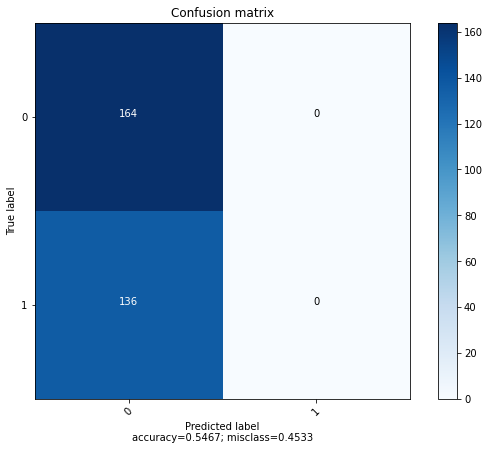

In [ ]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plot_confusion_matrix(cm)

Resposta

Com base no conjunto de teste, o modelo apresentou **acurácia de [XX]**.  
A análise por classe mostra que:

- **Classe 0**: precision = [..], recall = [..], F1-score = [..]
- **Classe 1**: precision = [..], recall = [..], F1-score = [..]

A **matriz de confusão** indica que os maiores acertos estão na diagonal principal, com:
- verdadeiros negativos (TN): [..]
- falsos positivos (FP): [..]
- falsos negativos (FN): [..]
- verdadeiros positivos (TP): [..]

Interpretação de generalização:
- Se precision/recall/F1 das duas classes estiverem próximos, a generalização é **boa e equilibrada**.
- Se houver diferença grande entre classes (ex.: recall muito baixo na classe 1), a generalização é **parcial**, com viés para a classe majoritária.
- Em base desbalanceada, a acurácia isolada pode superestimar desempenho; por isso, **F1 e recall por classe** são mais confiáveis para concluir sobre generalização.

Conclusão: o modelo [generaliza bem / generaliza de forma limitada], pois [justificativa com base nas métricas e na matriz].

3)	Agora normalize os dados de entrada e treine novamente o modelo MLP. Avalie os resultados obtidos e comente o efeito da normalização no treinamento da Rede Neural.

Rascunho

In [ ]:
new_df = transform_data(dataset, normalize=True)
new_df.head()

,ESTC,NDEP,RENDA,TIPOR,VBEM,NPARC,VPARC,TEL,IDADE,RESMS,ENTRADA,target
0,0.333333,0.0,0.007792,0.0,0.003514,0.347826,0.003026,0.0,0.117647,0.114286,0.0,1
1,0.000000,0.0,0.006494,1.0,0.045405,0.391304,0.022693,0.0,0.274510,0.014286,0.0,1
2,0.000000,0.0,0.103896,0.0,0.142973,0.347826,0.113464,0.0,0.725490,0.114286,0.0,1
3,0.000000,0.0,0.350649,0.0,0.068108,0.478261,0.039334,1.0,0.235294,0.142857,0.0,1
4,0.333333,0.0,0.090909,0.0,0.137568,0.478261,0.092284,0.0,0.098039,0.016667,0.0,1


In [ ]:
X = new_df.values[:,:-1].astype('float')
target = new_df.values[:,-1]

encoder = LabelEncoder()
y = encoder.fit_transform(target)

n_input = X.shape[1]

if np.unique(y).shape[0] <= 2:
  print('Binary classification')
  n_output = 1

else:
  print('Multiclass classification')
  #y = to_categorical(y)
  n_output = encoder.classes_.shape[0]


X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size=0.2,random_state=42)

Binary classification


In [ ]:
if binary:
    train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float().unsqueeze(1))
    val_dataset = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).float().unsqueeze(1))
    test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).float().unsqueeze(1))
else:
    train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).long())
    val_dataset = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).long())
    test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).long())

train_loader = DataLoader(dataset=train_dataset,batch_size=batch_size)
val_loader = DataLoader(dataset=val_dataset, batch_size=1)
test_loader = DataLoader(dataset=test_dataset, batch_size=1)

In [ ]:
model = NeuralNetwork(n_input = n_input, n_output=n_output,output_activation='sigmoid')
history, y_hat = train(model, train_loader, val_dataset, epochs=epochs, lr=lr, device=device, binary=binary)

  0%|          | 0/250 [00:00<?, ?it/s]

Epoch 001: | Train Loss: 0.684 | Val Loss: 0.6824 | Train Acc: 62.4667| Val Acc: 63.0000
Epoch 002: | Train Loss: 0.681 | Val Loss: 0.6798 | Train Acc: 64.2667| Val Acc: 64.0000
Epoch 003: | Train Loss: 0.678 | Val Loss: 0.6774 | Train Acc: 65.4333| Val Acc: 65.0000
Epoch 004: | Train Loss: 0.675 | Val Loss: 0.6753 | Train Acc: 66.0000| Val Acc: 64.0000
Epoch 005: | Train Loss: 0.673 | Val Loss: 0.6733 | Train Acc: 65.7667| Val Acc: 64.0000
Epoch 006: | Train Loss: 0.670 | Val Loss: 0.6713 | Train Acc: 65.6000| Val Acc: 65.0000
Epoch 007: | Train Loss: 0.668 | Val Loss: 0.6694 | Train Acc: 65.6333| Val Acc: 65.0000
Epoch 008: | Train Loss: 0.666 | Val Loss: 0.6674 | Train Acc: 66.2667| Val Acc: 66.0000
Epoch 009: | Train Loss: 0.663 | Val Loss: 0.6653 | Train Acc: 66.2667| Val Acc: 66.0000
Epoch 010: | Train Loss: 0.661 | Val Loss: 0.6632 | Train Acc: 66.3667| Val Acc: 67.0000
Epoch 011: | Train Loss: 0.658 | Val Loss: 0.6610 | Train Acc: 66.6000| Val Acc: 68.0000
Epoch 012: | Train Lo

Resposta

In [32]:
y_pred = model.predict(test_dataset.X_data,binary=binary)


NameError: name 'model' is not defined

              precision    recall  f1-score   support

           0       0.86      0.97      0.91       164
           1       0.96      0.82      0.88       136

    accuracy                           0.90       300
   macro avg       0.91      0.89      0.90       300
weighted avg       0.91      0.90      0.90       300



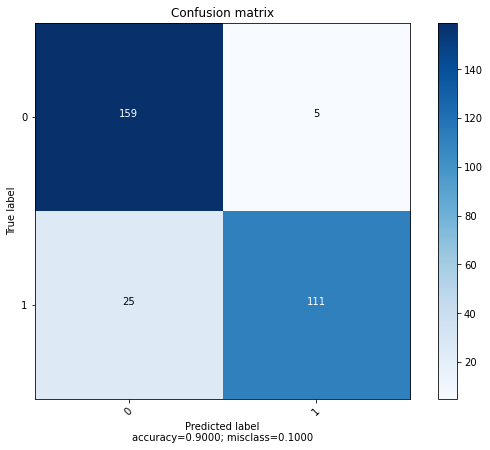

In [ ]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plot_confusion_matrix(cm)

## Parte 3 - Avaliando hiperparâmetros do modelo

1)	Modifique o tempo de treinamento (épocas) da Rede Neural. Escolha valores distintos (e.g. 1 e 1000 épocas) e avalie os resultados.

Rascunho

Resposta

2)	 Modifique a taxa de aprendizado da Rede Neural. Escolha valores distintos (e.g. 0,001 e 0,1) e avalie os resultados.

Rascunho

Resposta

3) Adicione o termo de *momentum* no algoritmo SGD. Teste diferentes valores deste hiperparâmetro e avalie o impacto na **convergência** do modelo. 

Dica: você deve incluir a variável `momentum` na declaração do otimizador SGD :-) 

Rascunho

Resposta

4)	Modifique a quantidade de neurônios na camada escondida da Rede Neural. Escolha valores distintos (e.g. 2 e 70 neurônios) e avalie os resultados.

Rascunho

Resposta

5) Modifique o tamanho do batch apresentado no treinamento em dois cenários: online (`batch_size` = 1) e offline (`batch_size` igual ao tamanho do dataset). Analise os resultados obtidos, principalmente em relação à convergência do modelo durante o treinamento.

Rascunho

Resposta

### Parte IV - Estratégias para aprimoramento de Redes Neurais. 

Total: 4,0 pts.

1)	Implemente a técnica de parada antecipada (Early Stopping).

OBS: para essa questão, crie uma nova função (e.g., `train_ES`) baseada no `train`. Essa função pode ser encontrada neste [código](https://github.com/mdrs-thiago/PUC_Redes_Neurais/blob/main/pos_grad/lista%201/model_utils.py), inserindo a lógica da parada antecipada.

Rascunho

Resposta

2)	Faça novos testes para avaliar o desempenho da Rede Neural no problema designado usando a técnica K-Fold (com K = 10). Comente o resultado obtido.

Dica: não é necessário utilizar a ferramenta KFold do scikit-learn para o desenvolvimento deste item. Uma alternativa <b> simples </b> é fazer um *for loop*, selecionando os índices em bloco. 

Rascunho

Resposta

3) Altere o **otimizador** do modelo de rede neural para algum de interesse (https://docs.pytorch.org/docs/stable/optim.html#algorithms). Execute em dois cenários: com e sem normalização. Avalie de que forma a mudança do otimizador altera o treinamento do modelo e sua generalização.

Rascunho

Resposta

4)	Faça análises e novas implementações que você julgue importante para o seu trabalho. Não esqueça de explicar a motivação da análise realizada. 

Rascunho

Resposta